# Custom Date-Range Backtest

Run the strategy over any window you choose and get the full performance breakdown.

**Models are frozen**: trained on 2015–2019, thresholds tuned on 2020–2021.  
Nothing is re-fitted regardless of what date range you pick.

**Supported range**: 2015-01-03 through 2026-05-15  
(dates before 2015-01-03 lack the 2-day lag history required for features)

---
**To use**: edit `START_DATE` and `END_DATE` in the cell below, then **Run All**.

In [23]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║              EDIT THESE TWO LINES — THEN RUN ALL CELLS              ║
# ╚══════════════════════════════════════════════════════════════════════╝

START_DATE = '2022-01-01'    # inclusive  (YYYY-MM-DD)
END_DATE   = '2025-12-31'    # inclusive  (YYYY-MM-DD)

# ── Everything below is automatic ────────────────────────────────────────────

In [24]:
import warnings; warnings.filterwarnings('ignore')
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT))
DATA   = PROJECT / 'data'
MODELS = PROJECT / 'models'
FEATS  = DATA / 'features'

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

ZONES       = ['CAPITL','CENTRL','DUNWOD','GENESE','HUDVL',
               'LONGIL','MHKVL','MILLWD','NORTH','NYC','WEST']
GAMMA_POS   = 5.0
GAMMA_NEG   = 30.0
TZ          = 'America/New_York'
HIST_END    = pd.Timestamp('2025-12-31 23:00:00', tz=TZ)   # main dataset boundary
LIVE_END    = pd.Timestamp('2026-05-15 23:00:00', tz=TZ)

# Parse user dates
t_start = pd.Timestamp(START_DATE + ' 00:00:00', tz=TZ)
t_end   = pd.Timestamp(END_DATE   + ' 23:00:00', tz=TZ)

if t_start < pd.Timestamp('2015-01-03', tz=TZ):
    raise ValueError('START_DATE must be >= 2015-01-03 (need 2 days of prior data for lags)')
if t_end > LIVE_END:
    raise ValueError(f'END_DATE must be <= 2026-05-15 (live data cutoff)')

print(f'Date range: {START_DATE}  to  {END_DATE}')
print(f'Spans {(t_end - t_start).days + 1} calendar days')

Date range: 2022-01-01  to  2025-12-31
Spans 1461 calendar days


In [25]:
# ── Load predictions and panel, handling historical / 2026 / cross-boundary ───

def _slice(df, start, end):
    """Filter a DatetimeIndex-indexed DataFrame to [start, end]."""
    return df[(df.index >= start) & (df.index <= end)]

def _load_predictions_for_range(t_start, t_end):
    """
    Return (predictions_df, dart_wide_df) for the requested window.
    - For dates fully in 2015-2025: use pre-computed predictions_naive.parquet (instant).
    - For any 2026 dates: rebuild predictions from panel_live_2026.parquet.
    - Cross-boundary: combine both.
    """
    preds_parts = []
    dart_parts  = []

    # Historical portion (2015-2025)
    hist_start = t_start
    hist_end   = min(t_end, HIST_END)
    if hist_start <= hist_end:
        print('Loading pre-computed predictions (2015-2025)...', end=' ', flush=True)
        preds_h = pd.read_parquet(FEATS / 'predictions_naive.parquet')
        preds_h = _slice(preds_h, hist_start, hist_end)

        panel_h = pd.read_parquet(DATA / 'processed' / 'panel.parquet')
        dart_h  = panel_h.pivot(
            index='interval_start_local', columns='zone', values='dart'
        )[ZONES]
        dart_h = _slice(dart_h, hist_start, hist_end)

        preds_parts.append(preds_h)
        dart_parts.append(dart_h)
        print(f'{len(preds_h):,} hours')

    # 2026 portion
    live_start = max(t_start, HIST_END + pd.Timedelta(hours=1))
    live_end   = min(t_end, LIVE_END)
    if live_start <= live_end:
        live_path = DATA / 'processed' / 'panel_live_2026.parquet'
        if not live_path.exists():
            raise FileNotFoundError(
                'panel_live_2026.parquet not found. '
                'Run: python -m nyiso_dart.data.download --start 2026 --end 2026 '
                'then: python -m nyiso_dart.data.build --years 2025 2026 '
                '      --output data/processed/panel_live_2026.parquet'
            )
        print('Rebuilding 2026 features (takes ~30 s)...', end=' ', flush=True)
        from nyiso_dart.features.build import build_features
        panel_l = pd.read_parquet(live_path)
        arts    = build_features(panel_l)
        X_l     = arts['X_naive']
        X_l     = _slice(X_l, live_start, live_end)

        # Apply all 22 models to get predictions
        preds_l = pd.DataFrame(index=X_l.index)
        valid   = X_l.notna().all(axis=1)
        for zone in ZONES:
            for side in ('pos', 'neg'):
                lbl  = f'{zone}_{side}'
                pipe = joblib.load(MODELS / 'naive' / f'{zone}_{side}.joblib')
                col  = pd.Series(np.nan, index=X_l.index)
                col[valid] = pipe.predict_proba(X_l[valid].values)[:, 1]
                preds_l[lbl] = col

        dart_l = panel_l.pivot(
            index='interval_start_local', columns='zone', values='dart'
        )[ZONES]
        dart_l = _slice(dart_l, live_start, live_end)

        preds_parts.append(preds_l)
        dart_parts.append(dart_l)
        print(f'{len(preds_l):,} hours')

    preds = pd.concat(preds_parts).sort_index() if preds_parts else pd.DataFrame()
    dart  = pd.concat(dart_parts).sort_index()  if dart_parts  else pd.DataFrame()
    return preds, dart

preds, dart_wide = _load_predictions_for_range(t_start, t_end)

print(f'\nPrediction matrix: {preds.shape[0]:,} hours x {preds.shape[1]} zone-sides')
print(f'DART matrix:       {dart_wide.shape[0]:,} hours x {dart_wide.shape[1]} zones')
print(f'Date range in data: {preds.index.min().date()} to {preds.index.max().date()}')

Loading pre-computed predictions (2015-2025)... 35,064 hours

Prediction matrix: 35,064 hours x 22 zone-sides
DART matrix:       35,064 hours x 11 zones
Date range in data: 2022-01-01 to 2025-12-31


In [26]:
# ── Apply thresholds, generate trades ────────────────────────────────────────
import holidays as hol
from nyiso_dart.config import season_of

thr  = pd.read_parquet(MODELS / 'thresholds_naive.parquet')
elig = thr[thr['eligible']].copy()
NY   = hol.country_holidays('US', subdiv='NY')

rows = []
for _, row in elig.iterrows():
    zone, side = row['zone'], row['side']
    tau        = float(row['best_tau'])
    lbl        = f'{zone}_{side}'
    if lbl not in preds.columns: continue

    p = preds[lbl]
    d = dart_wide[zone] if zone in dart_wide.columns else pd.Series(dtype=float)
    ok = p.notna() & d.notna() & (p >= tau)
    if not ok.any(): continue

    payoff = d[ok] if side == 'pos' else -d[ok]
    for t, pv, dv, pay in zip(ok[ok].index, p[ok], d[ok], payoff):
        rows.append({
            'time': t, 'zone': zone, 'side': side,
            'proba': float(pv), 'dart': float(dv), 'payoff': float(pay),
            'hour': t.hour, 'month': t.month,
            'season': season_of(t.month),
            'is_weekend': int(t.weekday() >= 5),
            'correct': bool(float(dv) >= GAMMA_POS if side == 'pos' else float(dv) <= -GAMMA_NEG),
        })

trades = pd.DataFrame(rows).sort_values('time').reset_index(drop=True)
n_hours   = len(preds)
n_days    = max(1, (preds.index.max() - preds.index.min()).days + 1)

print(f'Trades generated: {len(trades):,}  ({len(trades)/n_days:.1f} per day average)')
if len(trades) == 0:
    print('WARNING: no trades fired in this window. Try a wider range.')

Trades generated: 9,244  (6.3 per day average)


In [27]:
# ── Performance statistics ────────────────────────────────────────────────────
if len(trades) == 0:
    print('No trades — no statistics to compute.')
else:
    n         = len(trades)
    total_pnl = trades['payoff'].sum()
    wins      = trades[trades['payoff'] > 0]['payoff']
    losses    = trades[trades['payoff'] < 0]['payoff']
    win_rate  = len(wins) / n
    pf        = wins.sum() / abs(losses.sum()) if len(losses) else float('inf')
    precision = trades['correct'].mean()

    # Daily P&L for Sharpe
    hourly_pnl   = trades.groupby('time')['payoff'].sum().reindex(preds.index).fillna(0)
    daily_pnl    = hourly_pnl.resample('D').sum()
    sharpe_daily = (daily_pnl.mean() / daily_pnl.std() * np.sqrt(365)
                   if daily_pnl.std() > 0 else 0)

    # Drawdown
    cum_pnl = hourly_pnl.cumsum()
    max_dd  = float((cum_pnl - cum_pnl.cummax()).min())

    # Annualised
    years_frac = n_days / 365
    ann_pnl    = total_pnl / max(years_frac, 1/52)   # at least 1 week fraction

    print('=' * 55)
    print(f'  STRATEGY PERFORMANCE   {START_DATE}  to  {END_DATE}')
    print('=' * 55)
    print(f'  Calendar days in window  {n_days:>16,}')
    print(f'  Trades executed          {n:>16,}')
    print(f'  Trades per day (avg)     {n/n_days:>16.1f}')
    print()
    print(f'  Total P&L                ${total_pnl:>14,.2f}')
    print(f'  Annualised P&L (proj.)   ${ann_pnl:>14,.2f}')
    print()
    print(f'  Win rate                 {win_rate:>15.1%}')
    print(f'  Precision (spike hit)    {precision:>15.1%}')
    print(f'  Profit factor            {pf:>15.2f}x')
    print()
    print(f'  Avg winning trade        ${wins.mean():>14,.2f}')
    print(f'  Avg losing  trade        ${losses.mean():>14,.2f}')
    print(f'  Best single trade        ${trades["payoff"].max():>14,.2f}')
    print(f'  Worst single trade       ${trades["payoff"].min():>14,.2f}')
    print()
    print(f'  Sharpe (daily, ann.)     {sharpe_daily:>16.2f}')
    print(f'  Max drawdown             ${max_dd:>14,.2f}')
    print('=' * 55)
    print()
    print('By side:')
    print(trades.groupby('side')[['payoff']].agg(
        count=('payoff','size'), total=('payoff','sum'), avg=('payoff','mean')
    ).round(2).to_string())

  STRATEGY PERFORMANCE   2022-01-01  to  2025-12-31
  Calendar days in window             1,461
  Trades executed                     9,244
  Trades per day (avg)                  6.3

  Total P&L                $    140,303.00
  Annualised P&L (proj.)   $     35,051.74

  Win rate                           73.7%
  Precision (spike hit)              68.4%
  Profit factor                       1.79x

  Avg winning trade        $         46.58
  Avg losing  trade        $        -72.83
  Best single trade        $      4,166.13
  Worst single trade       $     -2,802.52

  Sharpe (daily, ann.)                 1.58
  Max drawdown             $    -23,907.65

By side:
      count     total     avg
side                         
neg      93   21292.8  228.95
pos    9151  119010.2   13.01


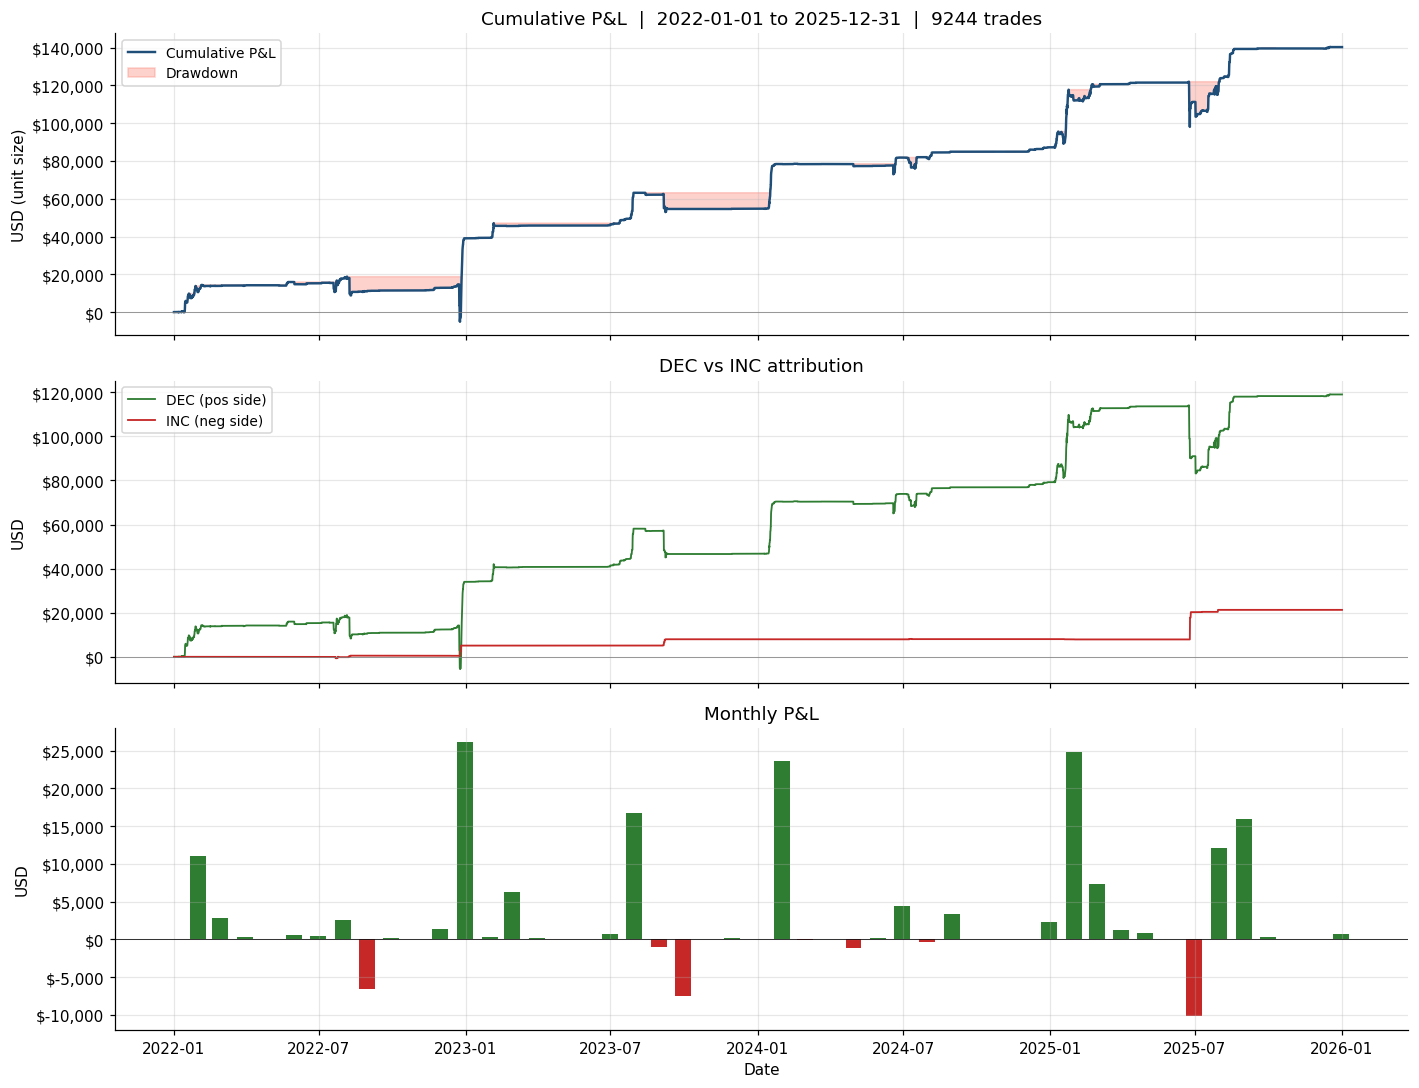

In [28]:
if len(trades) == 0:
    print('No trades to plot.')
else:
    hourly_pnl = trades.groupby('time')['payoff'].sum().reindex(preds.index).fillna(0)
    cum_pnl    = hourly_pnl.cumsum()
    running_max = cum_pnl.cummax()
    drawdown    = cum_pnl - running_max

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

    # Panel 1: cumulative P&L with drawdown shaded
    ax = axes[0]
    ax.plot(cum_pnl.index, cum_pnl.values, lw=1.6, color='#1f4e79', label='Cumulative P&L')
    ax.fill_between(cum_pnl.index, cum_pnl.values, running_max.values,
                    where=cum_pnl.values < running_max.values,
                    color='salmon', alpha=0.35, label='Drawdown')
    ax.axhline(0, color='grey', lw=0.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_title(f'Cumulative P&L  |  {START_DATE} to {END_DATE}  |  {n} trades')
    ax.set_ylabel('USD (unit size)')
    ax.legend(loc='upper left', fontsize=9)

    # Panel 2: DEC vs INC
    ax = axes[1]
    pos_h = trades[trades['side']=='pos'].groupby('time')['payoff'].sum().reindex(preds.index).fillna(0)
    neg_h = trades[trades['side']=='neg'].groupby('time')['payoff'].sum().reindex(preds.index).fillna(0)
    ax.plot(cum_pnl.index, pos_h.cumsum(), lw=1.2, color='#2e7d32', label='DEC (pos side)')
    ax.plot(cum_pnl.index, neg_h.cumsum(), lw=1.2, color='#c62828', label='INC (neg side)')
    ax.axhline(0, color='grey', lw=0.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_ylabel('USD'); ax.legend(loc='upper left', fontsize=9)
    ax.set_title('DEC vs INC attribution')

    # Panel 3: rolling monthly P&L bars
    ax = axes[2]
    monthly = trades.groupby(pd.Grouper(key='time', freq='ME'))['payoff'].sum()
    colors  = ['#2e7d32' if v >= 0 else '#c62828' for v in monthly]
    ax.bar(monthly.index, monthly.values, color=colors, width=20)
    ax.axhline(0, color='black', lw=0.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_ylabel('USD'); ax.set_xlabel('Date')
    ax.set_title('Monthly P&L')

    plt.tight_layout()
    plt.show()

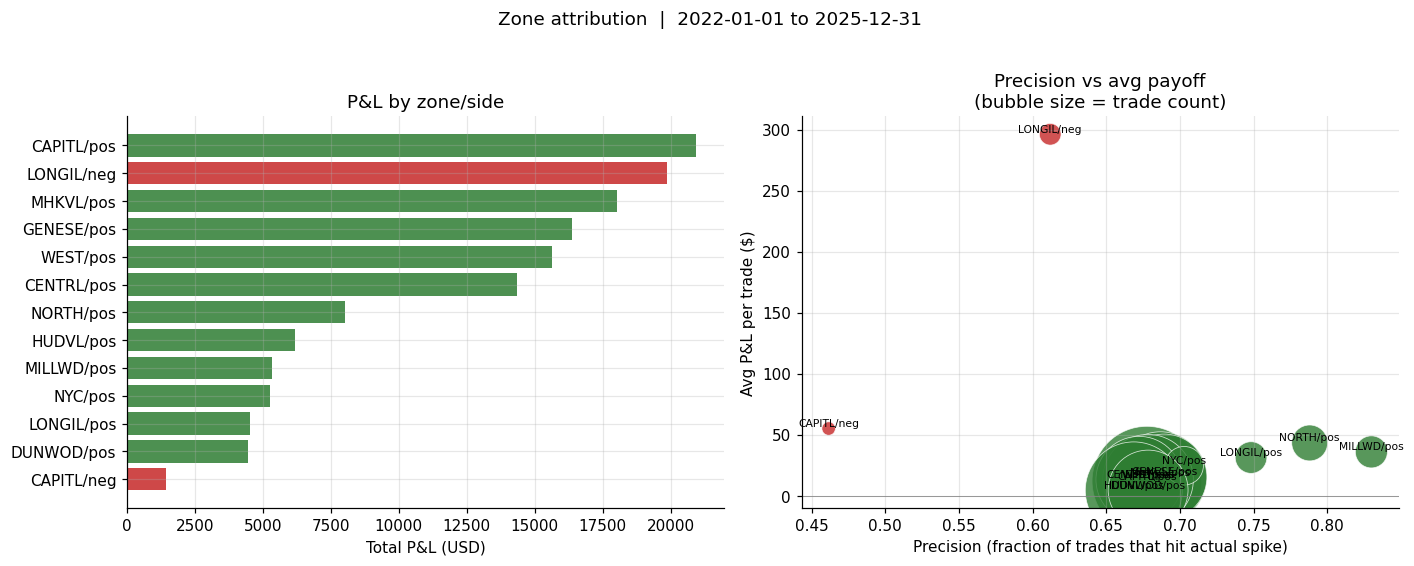

Full attribution table:
Zone     Side    Trades  Precision    Total P&L  Avg/trade
----------------------------------------------------------
CAPITL   pos       1715      67.8% $ 20,929.17 $   12.20
LONGIL   neg         67      61.2% $ 19,855.51 $  296.35
MHKVL    pos       1210      68.7% $ 18,021.67 $   14.89
GENESE   pos       1049      68.9% $ 16,381.11 $   15.62
WEST     pos       1172      67.8% $ 15,621.25 $   13.33
CENTRL   pos       1065      67.2% $ 14,353.53 $   13.48
NORTH    pos        184      78.8% $  7,999.27 $   43.47
HUDVL    pos       1343      66.9% $  6,186.58 $    4.61
MILLWD   pos        147      83.0% $  5,314.11 $   36.15
NYC      pos        212      70.3% $  5,260.77 $   24.81
LONGIL   pos        143      74.8% $  4,506.14 $   31.51
DUNWOD   pos        911      67.8% $  4,436.60 $    4.87
CAPITL   neg         26      46.2% $  1,437.29 $   55.28


In [29]:
if len(trades) == 0:
    print('No trades.')
else:
    zone_attr = (
        trades.groupby(['zone','side'])
        .agg(n_trades=('payoff','size'),
             total_pnl=('payoff','sum'),
             avg_pnl=('payoff','mean'),
             precision=('correct','mean'))
        .sort_values('total_pnl', ascending=False)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    labels  = zone_attr['zone'] + '/' + zone_attr['side']
    colors  = ['#2e7d32' if s=='pos' else '#c62828' for s in zone_attr['side']]
    ax.barh(labels[::-1], zone_attr['total_pnl'][::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('Total P&L (USD)')
    ax.set_title('P&L by zone/side')

    ax = axes[1]
    elig_zones = zone_attr[zone_attr['n_trades'] > 0]
    ax.scatter(elig_zones['precision'], elig_zones['avg_pnl'],
               c=['#2e7d32' if s=='pos' else '#c62828' for s in elig_zones['side']],
               s=elig_zones['n_trades'] * 3, alpha=0.8, edgecolors='white', linewidth=0.5)
    for _, r in elig_zones.iterrows():
        ax.annotate(f"{r.zone}/{r.side}", (r.precision, r.avg_pnl),
                    fontsize=7, ha='center', va='bottom')
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_xlabel('Precision (fraction of trades that hit actual spike)')
    ax.set_ylabel('Avg P&L per trade ($)')
    ax.set_title('Precision vs avg payoff\n(bubble size = trade count)')

    plt.suptitle(f'Zone attribution  |  {START_DATE} to {END_DATE}', y=1.02)
    plt.tight_layout()
    plt.show()

    print('Full attribution table:')
    print(f"{'Zone':8s} {'Side':5s} {'Trades':>8s} {'Precision':>10s} {'Total P&L':>12s} {'Avg/trade':>10s}")
    print('-' * 58)
    for _, r in zone_attr.iterrows():
        print(f"{r.zone:8s} {r.side:5s} {r.n_trades:>8.0f} {r.precision:>10.1%} "
              f"${r.total_pnl:>10,.2f} ${r.avg_pnl:>8,.2f}")

In [30]:
if len(trades) > 0:
    print('Monthly P&L breakdown:')
    trades['ym'] = trades['time'].dt.to_period('M')
    monthly_tbl = trades.groupby('ym').agg(
        n_trades=('payoff','size'),
        total_pnl=('payoff','sum'),
        win_rate=('payoff', lambda x: (x>0).mean()),
        avg_trade=('payoff','mean'),
    ).round(2)
    monthly_tbl['cumulative'] = monthly_tbl['total_pnl'].cumsum()
    print(monthly_tbl.to_string(float_format=lambda x: f'{x:,.2f}'))

Monthly P&L breakdown:
         n_trades  total_pnl  win_rate  avg_trade  cumulative
ym                                                           
2022-01       679  11,076.87      0.70      16.31   11,076.87
2022-02       232   2,806.26      0.70      12.10   13,883.13
2022-03        46     332.21      0.59       7.22   14,215.34
2022-04         1     -14.11      0.00     -14.11   14,201.23
2022-05        42     557.49      0.67      13.27   14,758.72
2022-06        51     482.70      0.69       9.46   15,241.42
2022-07       376   2,576.83      0.66       6.85   17,818.25
2022-08       320  -6,557.18      0.61     -20.49   11,261.07
2022-09        19     189.63      0.68       9.98   11,450.70
2022-11        66   1,416.71      0.94      21.47   12,867.41
2022-12       590  26,199.24      0.88      44.41   39,066.65
2023-01        21     273.37      1.00      13.02   39,340.02
2023-02       204   6,263.76      0.72      30.70   45,603.78
2023-03        15     213.42      0.87      14.

In [31]:
# ── Annual run-rate context vs the full 2022-2025 test ────────────────────────
if len(trades) > 0:
    full_test = pd.read_parquet(PROJECT / 'results' / 'naive' / 'trades.parquet')
    full_pnl  = full_test['payoff'].sum()
    full_days = (full_test['interval_start_local'].max() -
                 full_test['interval_start_local'].min()).days
    full_ann  = full_pnl / (full_days / 365)
    this_ann  = total_pnl / max(years_frac, 1/52)

    print('Context vs the full 2022-2025 test period:')
    print(f'  Full test 2022-2025:   ${full_pnl:>12,.2f}  total  |  ${full_ann:>10,.2f}/yr annualised')
    print(f'  Your window:           ${total_pnl:>12,.2f}  total  |  ${this_ann:>10,.2f}/yr annualised')
    print()
    print(f'  Your window spans {n_days} days ({years_frac:.2f} years).')
    if n_days < 90:
        print('  Note: short windows are noisy. A few large DART events can')
        print('  dominate P&L. Interpret with caution.')

Context vs the full 2022-2025 test period:
  Full test 2022-2025:   $  140,303.00  total  |  $ 35,538.23/yr annualised
  Your window:           $  140,303.00  total  |  $ 35,051.74/yr annualised

  Your window spans 1461 days (4.00 years).


In [32]:
# ── Individual trade log (top 20 by absolute payoff) ─────────────────────────
if len(trades) > 0:
    print(f'Top 15 trades in this window (by absolute payoff):')
    top = trades.reindex(trades['payoff'].abs().sort_values(ascending=False).index).head(15)
    print(f"{'Time':25s} {'Zone':8s} {'Side':5s} {'Prob':>6s} {'DART':>8s} {'Payoff':>9s} {'Hit?':>5s}")
    print('-' * 72)
    for _, r in top.iterrows():
        print(f"{str(r.time)[:22]:25s} {r.zone:8s} {r.side:5s} "
              f"{r.proba:>6.2f} {r.dart:>8.2f} ${r.payoff:>8.2f}  {'Y' if r.correct else 'N':>4s}")

Top 15 trades in this window (by absolute payoff):
Time                      Zone     Side    Prob     DART    Payoff  Hit?
------------------------------------------------------------------------
2025-06-24 18:00:00-04    LONGIL   neg     0.77 -4166.13 $ 4166.13     Y
2025-06-24 17:00:00-04    LONGIL   neg     0.69 -3500.78 $ 3500.78     Y
2022-12-24 08:00:00-05    HUDVL    pos     0.55 -2802.52 $-2802.52     N
2022-12-24 07:00:00-05    CAPITL   pos     0.55 -2752.29 $-2752.29     N
2022-12-24 08:00:00-05    CAPITL   pos     0.59 -2697.93 $-2697.93     N
2022-12-25 21:00:00-05    LONGIL   neg     0.77 -2503.48 $ 2503.48     Y
2025-07-01 16:00:00-04    DUNWOD   pos     0.61 -2502.43 $-2502.43     N
2022-12-23 19:00:00-05    HUDVL    pos     0.53 -2459.70 $-2459.70     N
2025-07-01 17:00:00-04    DUNWOD   pos     0.75 -2072.12 $-2072.12     N
2025-07-25 15:00:00-04    DUNWOD   pos     0.78 -2027.26 $-2027.26     N
2022-12-23 19:00:00-05    CAPITL   pos     0.65 -1790.06 $-1790.06     N
